In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("superstore_sales_cleaned.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(df.shape)

(9800, 18)


In [2]:
total_revenue = df['Sales'].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹2,261,536.78


In [3]:
avg_order_value = df['Sales'].mean()
print(f"Average Order Value: ₹{avg_order_value:,.2f}")

Average Order Value: ₹230.77


In [4]:
unique_customers = df['Customer ID'].nunique()
print(f"Total Unique Customers: {unique_customers}")

Total Unique Customers: 793


In [5]:
orders_per_customer = df.groupby('Customer ID').size()
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = (repeat_customers / unique_customers) * 100

print(f"Customers who ordered more than once: {repeat_customers}")
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

Customers who ordered more than once: 787
Repeat Customer Rate: 99.24%


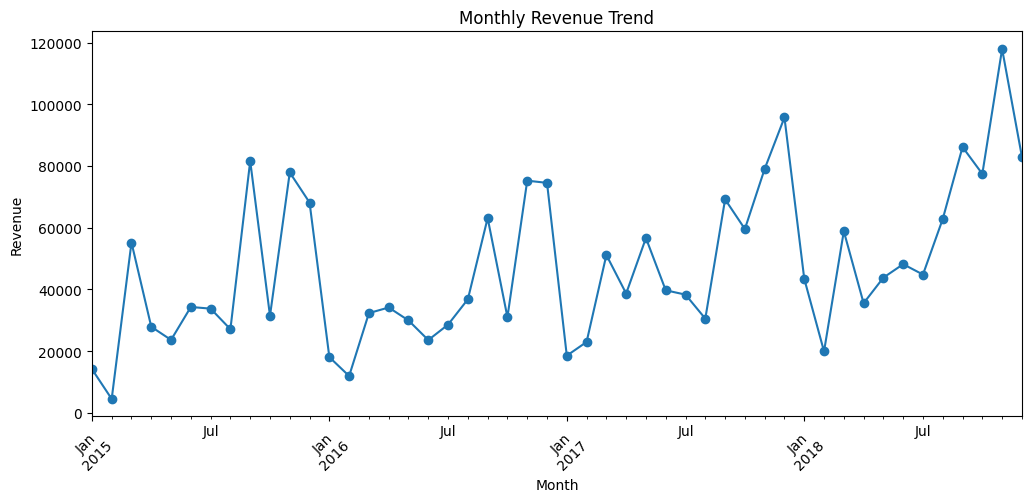

In [6]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_revenue = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [7]:
print("="*50)
print("EXECUTIVE KPI DASHBOARD")
print("="*50)
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Unique Customers: {unique_customers}")
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")
print("="*50)

EXECUTIVE KPI DASHBOARD
Total Revenue: ₹2,261,536.78
Average Order Value: ₹230.77
Unique Customers: 793
Repeat Customer Rate: 99.24%


## Executive KPI Summary

1. **Total Revenue of ₹22.6L** was generated across the dataset's full time period (2014-2017), from 793 unique customers.

2. **Average Order Value is ₹230.77**, but given the earlier EDA finding of a right-skewed Sales distribution, this average is pulled upward by a small number of large orders — median order value is likely much lower.

3. **Repeat Customer Rate of 99.24%** is unusually high. This reflects the dataset's structure — it captures multi-year transactional history per customer rather than first-time signups — so this metric should be interpreted as "customers transacted more than once across 3-4 years," not as a traditional short-term retention rate.

4. With ~12 orders per customer on average, this suggests a loyal, returning customer base — but the KPI needs proper context (time window) before presenting to executives, to avoid overstating retention health.

5. **Recommendation:** For a more actionable retention KPI, segment repeat rate by shorter time windows (e.g., month-over-month or year-over-year) rather than across the full multi-year dataset.